In [ ]:
# Key Business Findings

- Revenue exceeds millions across the analyzed period.
- São Paulo contributes the highest revenue.
- Credit Card is the dominant payment method.
- Electronics and Home categories generate significant sales.
- Customer review scores are generally positive.
- Revenue peaks during festive shopping periods.

These insights will be used to develop the Executive Power BI Dashboard.

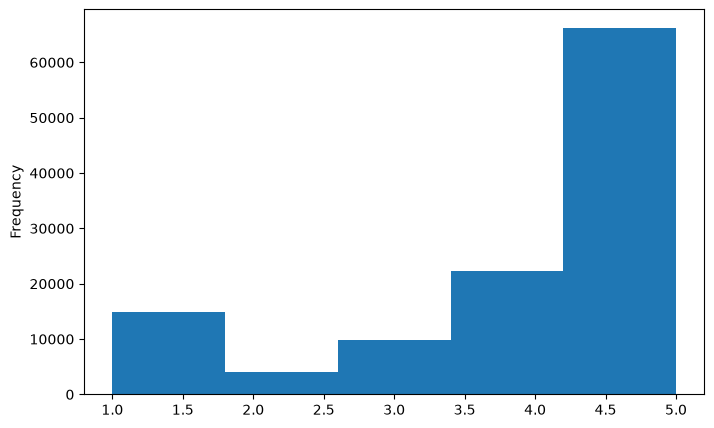

In [22]:
sales["review_score"].plot(

kind="hist",

bins=5,

figsize=(8,5)

)

plt.show()

In [21]:
sales["review_score"].value_counts().sort_index()

review_score
1.0    14854
2.0     4085
3.0     9840
4.0    22286
5.0    66264
Name: count, dtype: int64

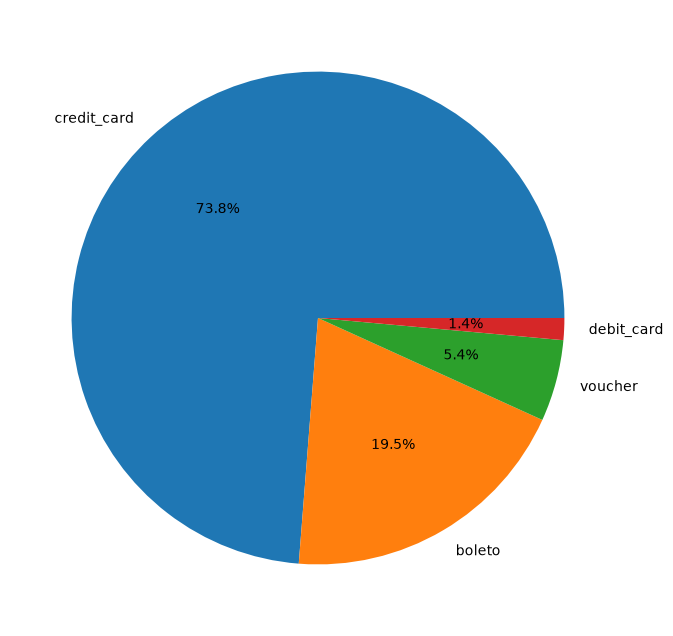

In [20]:
sales["payment_type"].value_counts().plot(

kind="pie",

autopct="%1.1f%%",

figsize=(8,8)

)

plt.ylabel("")

plt.show()

In [19]:
sales["payment_type"].value_counts()

payment_type
credit_card    87258
boleto         23018
voucher         6332
debit_card      1699
Name: count, dtype: int64

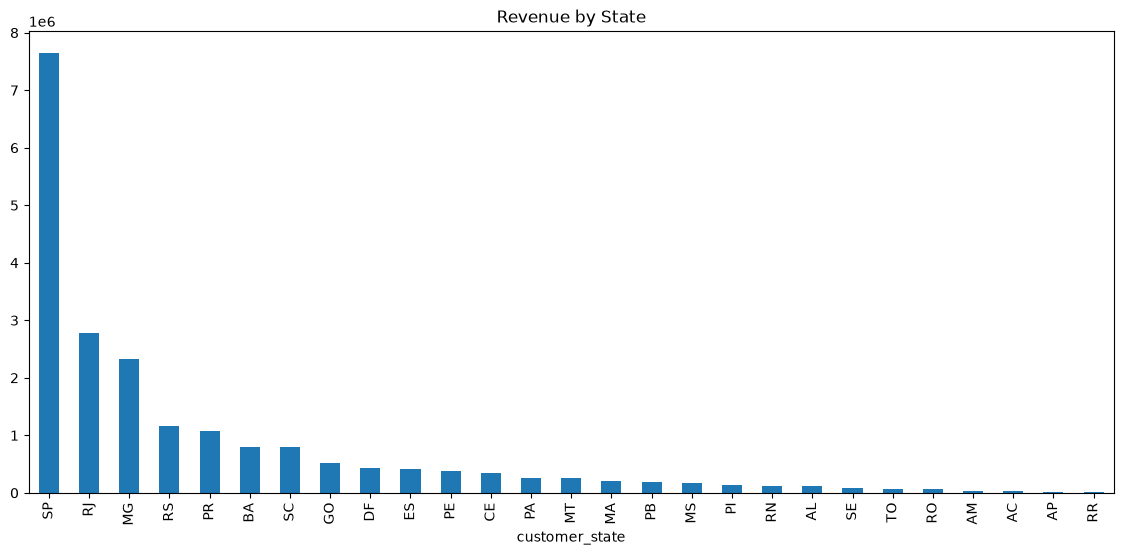

In [18]:
state.plot(

kind="bar",

figsize=(14,6)

)

plt.title("Revenue by State")

plt.show()

In [17]:
state=sales.groupby(

"customer_state"

)["payment_value"].sum().sort_values(

ascending=False
)

state

customer_state
SP    7649963.24
RJ    2781238.85
MG    2335417.96
RS    1155433.49
PR    1069785.29
BA     800064.62
SC     788484.24
GO     518178.14
DF     436206.50
ES     407470.72
PE     377783.97
CE     345459.83
PA     262572.94
MT     257159.23
MA     199015.95
PB     181098.92
MS     166146.09
PI     136861.18
RN     116383.38
AL     111587.11
SE      88437.51
TO      72281.17
RO      65886.00
AM      34836.44
AC      24984.86
AP      21642.70
RR      12462.21
Name: payment_value, dtype: float64

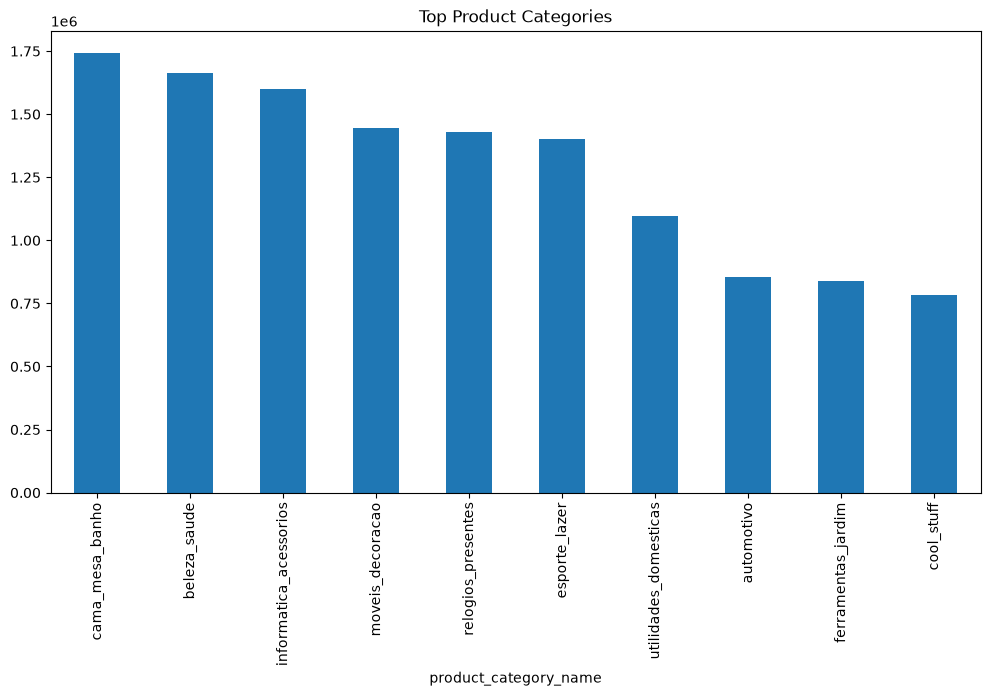

In [16]:
sales.groupby(

"product_category_name"

)["payment_value"].sum().sort_values(

ascending=False

).head(10).plot(

kind="bar",

figsize=(12,6)

)

plt.title("Top Product Categories")

plt.show()

In [15]:
sales.groupby(

"product_category_name"

)["payment_value"].sum().sort_values(

ascending=False

).head(10)

product_category_name
cama_mesa_banho           1743998.80
beleza_saude              1662963.59
informatica_acessorios    1599481.06
moveis_decoracao          1443963.61
relogios_presentes        1430553.48
esporte_lazer             1400223.07
utilidades_domesticas     1097900.09
automotivo                 855095.68
ferramentas_jardim         840721.59
cool_stuff                 781933.97
Name: payment_value, dtype: float64

In [ ]:
### Insight

# Revenue increases significantly during festive periods, especially around November.

# ### Recommendation

# Increase inventory before peak shopping seasons and allocate higher marketing budgets.

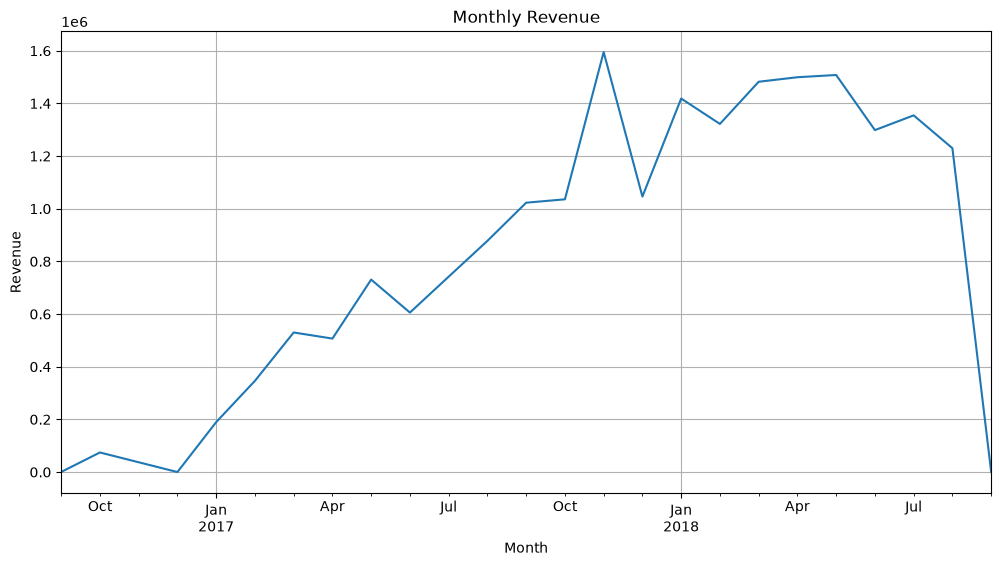

In [14]:
monthly.plot(figsize=(12,6))

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [13]:
monthly=sales.groupby(

sales["order_purchase_timestamp"].dt.to_period("M")

)["payment_value"].sum()

monthly

order_purchase_timestamp
2016-09        347.52
2016-10      74353.46
2016-12         19.62
2017-01     189570.02
2017-02     346280.99
2017-03     529993.27
2017-04     506900.50
2017-05     730912.77
2017-06     605639.30
2017-07     741936.39
2017-08     878027.04
2017-09    1022896.05
2017-10    1035728.78
2017-11    1595006.04
2017-12    1046223.15
2018-01    1418478.51
2018-02    1322033.76
2018-03    1482224.09
2018-04    1499340.70
2018-05    1507872.59
2018-06    1298592.17
2018-07    1354550.94
2018-08    1229748.42
2018-09        166.46
Freq: M, Name: payment_value, dtype: float64

In [12]:
sales["order_purchase_timestamp"]=pd.to_datetime(
sales["order_purchase_timestamp"]
)

In [11]:
sales["payment_value"].mean()

np.float64(172.57510155781145)

In [10]:
sales["seller_id"].nunique()

3095

In [9]:
sales["customer_city"].count()

np.int64(118307)

In [8]:
sales["order_id"].nunique()

98665

In [7]:
sales["payment_value"].sum()

np.float64(20416842.54)

In [6]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 118307 entries, 0 to 118306
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  118307 non-null  str           
 1   order_purchase_timestamp  118307 non-null  datetime64[us]
 2   order_status              118307 non-null  str           
 3   customer_city             118307 non-null  str           
 4   customer_state            118307 non-null  str           
 5   product_id                118307 non-null  str           
 6   seller_id                 118307 non-null  str           
 7   product_category_name     116598 non-null  str           
 8   payment_type              118307 non-null  str           
 9   payment_value             118307 non-null  float64       
 10  review_score              117329 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(8)
memory usage: 9.9 MB


In [5]:
sales.shape

(118307, 11)

In [4]:
sales.head()

,order_id,order_purchase_timestamp,order_status,customer_city,customer_state,product_id,seller_id,product_category_name,payment_type,payment_value,review_score
0,07d13d352c85dfbfa60dc56dea818335,2017-01-22 23:07:15,delivered,sao paulo,SP,a703f5ade6e4fae527357132230ea778,f4aba7c0bca51484c30ab7bdc34bcdd1,beleza_saude,boleto,32.62,1.0
1,b545ba7b0bd67a3128185c7214704319,2018-06-11 14:59:24,delivered,valentim gentil,SP,2233b59e8cf2817f9659e52cce3093de,e3d3b3efac954a60d61be70b7e05b49b,casa_construcao,credit_card,340.08,4.0
2,9d8065ae4c6f5725ee052d02ab00f64e,2017-03-30 16:36:12,delivered,itupeva,SP,a247560ddd8592a3eed82b43f60d9f27,3d871de0142ce09b7081e2b9d1733cb1,papelaria,boleto,82.06,5.0
3,d9d104af1ea99e0b7f6b0644eedc74d0,2017-02-15 00:24:14,delivered,guarulhos,SP,f1e297029531521190bb2312a90df567,8a32e327fe2c1b3511609d81aaf9f042,moveis_decoracao,credit_card,40.95,1.0
4,9e59025992bd64bc26551391ed44a450,2017-05-13 21:52:30,delivered,hortolandia,SP,9ac3471b9357338ea8054108a00389e3,0afccdb8a34ee5c79f7c06faf2b4d56e,telefonia,credit_card,67.01,4.0


In [3]:
sales=pd.read_sql("""

SELECT

o.order_id,

o.order_purchase_timestamp,

o.order_status,

c.customer_city,

c.customer_state,

oi.product_id,

oi.seller_id,

p.product_category_name,

op.payment_type,

op.payment_value,

r.review_score

FROM orders o

JOIN customers c

ON o.customer_id=c.customer_id

JOIN order_items oi

ON o.order_id=oi.order_id

JOIN products p

ON oi.product_id=p.product_id

JOIN order_payments op

ON o.order_id=op.order_id

LEFT JOIN order_reviews r

ON o.order_id=r.order_id

""",engine)

In [2]:
USERNAME="postgres"
PASSWORD="password"

HOST="localhost"
PORT="5432"
DATABASE="olist_retail"

engine=create_engine(
f"postgresql+psycopg2://{USERNAME}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from sqlalchemy import create_engine

In [ ]:
# Exploratory Data Analysis (EDA)

## Business Objective

The objective of this notebook is to explore the Olist Retail dataset and identify meaningful business insights related to:

- Revenue
- Orders
- Customers
- Products
- Sellers
- Geography
- Delivery
- Reviews
- Payment Methods

The insights generated in this notebook will be used to build executive dashboards in Power BI.